In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
df = pd.read_csv("adult.csv")
print(df.head())


   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

In [4]:
df.replace(" ?", np.nan, inplace=True)
df.dropna(inplace=True)

In [5]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [6]:
X = df.drop("income", axis=1)
y = df["income"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = Sequential()


model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))


model.add(Dense(32, activation='relu'))


model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [10]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6345 - loss: 293.3510 - val_accuracy: 0.7685 - val_loss: 1.0659
Epoch 2/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7293 - loss: 4.4115 - val_accuracy: 0.7687 - val_loss: 0.5806
Epoch 3/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7466 - loss: 1.6107 - val_accuracy: 0.7685 - val_loss: 0.5498
Epoch 4/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7521 - loss: 0.8781 - val_accuracy: 0.7683 - val_loss: 0.5429
Epoch 5/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7553 - loss: 0.8666 - val_accuracy: 0.7687 - val_loss: 0.5410
Epoch 6/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7560 - loss: 0.7957 - val_accuracy: 0.7685 - val_loss: 0.5411
Epoch 7/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7554 - loss: 0.6724 - val_accuracy: 0.7693 - val_loss: 0.5398
Epoch 8/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7571 - loss: 0.6973 - val_accuracy: 

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy =", accuracy)

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7640 - loss: 0.5466
Accuracy = 0.7640104293823242


In [12]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4976    0]
 [1537    0]]


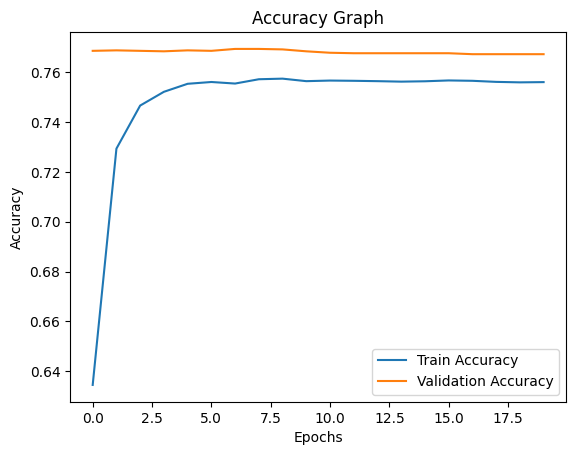

In [14]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


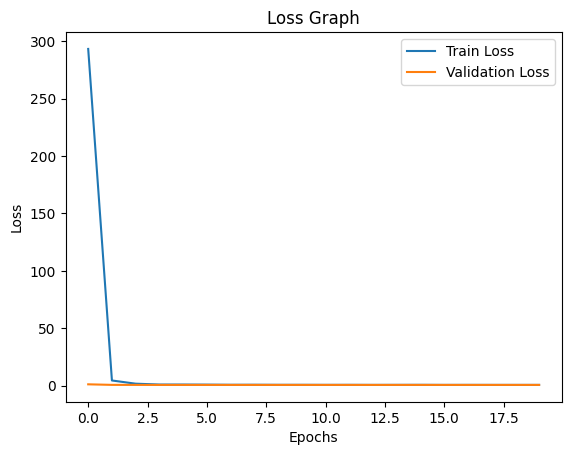

Overfitting: Train accuracy high, validation low
Underfitting: Both accuracies low
Dropout helps reduce overfitting


In [16]:
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
print("Overfitting: Train accuracy high, validation low")
print("Underfitting: Both accuracies low")
print("Dropout helps reduce overfitting")